# Assignment 1: Building Neural Networks for Image Classification

## Overview
Welcome to Assignment 1! In this assignment, you'll dive into the fascinating realm of deep learning by building and training neural networks for image classification using the PyTorch framework. You'll work with two popular datasets: MNIST for image classification and CIFAR-100 for object classification. Throughout the assignment, you'll also fine-tune your models to achieve optimal results.

## Part 1: Image Classification on MNIST
In the first part of the assignment, your goal is to construct both a fully connected neural network and a convolutional neural network (CNN) for image classification using the MNIST dataset. The MNIST dataset consists of 28x28 grayscale images of handwritten digits (0-9). Your task is to build models that can accurately classify these digits.

**NOTE: Please make sure you complete ALL the TODOs and missing codes in both .py and .ipynb files. Then you should complete the PDF report**

# Part 1a: Simple Fully Connected Neural Network - MNIST Classification

# Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# ONLY torch/numpy/matplotlib imports allowed here

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
from data import get_dataloaders
import neural_network
import trainer
import visualize

# Load MNIST Dataset

In [3]:
# Hyperparameters
# TODO: Experiment with different hyperparameters
batch_size = 32
learning_rate = 0.001
epochs = 10

In [4]:
# Load MNIST dataset
trainloader, testloader = get_dataloaders(dataset_name="mnist", batch_size=batch_size)

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


# Initialise Fully Connected neural network Archictecture

In [5]:
fc_model = neural_network.FCModel()

# Print the model architecture
print(fc_model)

# Define optimizers for the models
# TODO: Create an optimizer for the FCModel, use SGD, Adam or AdamW with defined learning_rate
optimizer = torch.optim.Adam(fc_model.parameters(), lr=learning_rate)

#TODO: define loss function using torch.nn that would be best for your usecase
criterion = nn.CrossEntropyLoss()

FCModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
# TODO: Train the fully connected model and record losses
# Use the train function to train the fc_model with optimizer on the trainloader for a specified number of epochs (e.g., 5)
# Define Hyperparameters here
# Record the training and test losses in fc_train_losses and fc_test_losses respectively, pass hyperparameters
fc_train_losses, fc_test_losses = trainer.train(
    fc_model, optimizer, criterion, trainloader, testloader, epochs, device
)

Epoch 1/10 - Train Loss: 0.29624377591510614
Epoch 1/10 - Test Loss: 0.16259756075410237
Epoch 1/10 - Test Accuracy: 94.89%
Epoch 2/10 - Train Loss: 0.14108561231258016
Epoch 2/10 - Test Loss: 0.1336691422194459
Epoch 2/10 - Test Accuracy: 95.71%
Epoch 3/10 - Train Loss: 0.10795889060404151
Epoch 3/10 - Test Loss: 0.1312990845439077
Epoch 3/10 - Test Accuracy: 96.05%
Epoch 4/10 - Train Loss: 0.09081220534425229
Epoch 4/10 - Test Loss: 0.11357442003794475
Epoch 4/10 - Test Accuracy: 96.38%
Epoch 5/10 - Train Loss: 0.07595942877948594
Epoch 5/10 - Test Loss: 0.11267980387369368
Epoch 5/10 - Test Accuracy: 96.66%
Epoch 6/10 - Train Loss: 0.06947843639721007
Epoch 6/10 - Test Loss: 0.0992029434416215
Epoch 6/10 - Test Accuracy: 96.99%
Epoch 7/10 - Train Loss: 0.058610584024906466
Epoch 7/10 - Test Loss: 0.12635750575798205
Epoch 7/10 - Test Accuracy: 96.34%
Epoch 8/10 - Train Loss: 0.05593168112761341
Epoch 8/10 - Test Loss: 0.10549774957460253
Epoch 8/10 - Test Accuracy: 97.23%
Epoch 9/10

In [7]:
# Evaluate the models
fc_accuracy = trainer.evaluate_accuracy(fc_model, testloader, device)

# Print test accuracy
print("Fully Connected Model Test Accuracy:", fc_accuracy)

Fully Connected Model Test Accuracy: 97.41


# Visualize Final Results: FCN- MNIST

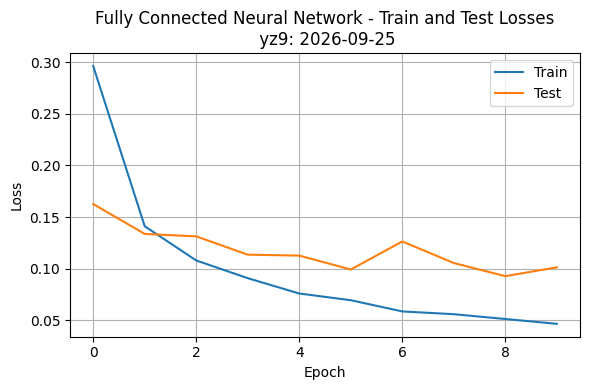

In [8]:
# Plot train and test losses for the fully connected neural network
visualize.visualize_loss(fc_train_losses, fc_test_losses, "Fully Connected Neural Network")

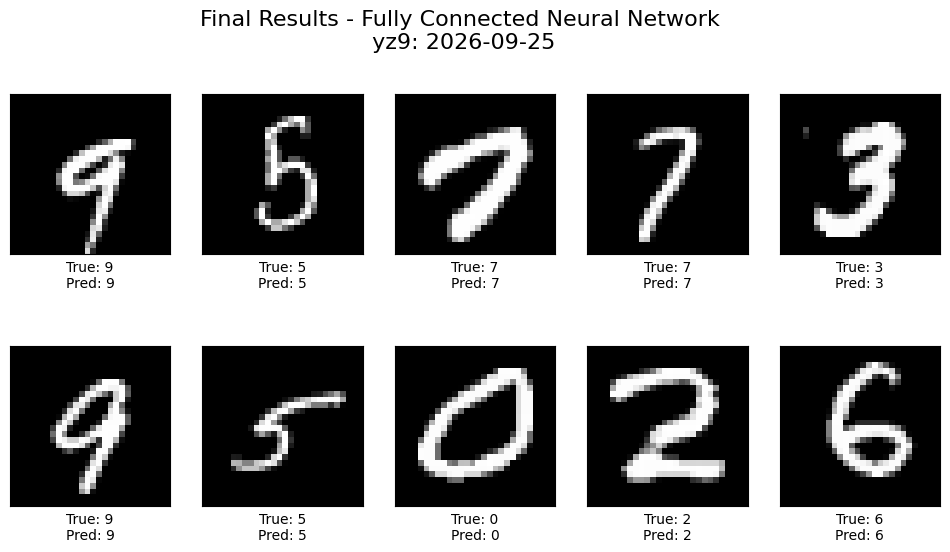

In [9]:
# Visualize the final results
visualize.visualize_images(fc_model, testloader.dataset, device, "Fully Connected Neural Network")

# Part 1b: Convolutional Neural Network Architecture - MNIST Classification


# Load Dataset and Transforms

In [10]:
cnn_model = neural_network.CNNModel()

# Print the model architecture
print(cnn_model)

# Define optimizers for the models
# TODO: Create a new optimizer for the CNNModel, use SGD, Adam or AdamW with defined learning_rate
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=learning_rate)

criterion = nn.CrossEntropyLoss()

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=12544, out_features=10, bias=True)
)


In [11]:
# TODO: Train the CNN model and record losses
# Use the train function to train the cnn_model with optimizer on the trainloader for a specified number of epochs (e.g., 5)
# Define Hyperparameters here
# Record the training and test losses in cnn_train_losses and cnn_test_losses respectively, pass hyperparameters
cnn_train_losses, cnn_test_losses = trainer.train(
    cnn_model, optimizer, criterion, trainloader, testloader, epochs, device
)

Epoch 1/10 - Train Loss: 0.12345759324477985
Epoch 1/10 - Test Loss: 0.038253633525196874
Epoch 1/10 - Test Accuracy: 98.82%
Epoch 2/10 - Train Loss: 0.0437163858274774
Epoch 2/10 - Test Loss: 0.035347142196763895
Epoch 2/10 - Test Accuracy: 98.86%
Epoch 3/10 - Train Loss: 0.03068026398489407
Epoch 3/10 - Test Loss: 0.0452690352085483
Epoch 3/10 - Test Accuracy: 98.71%
Epoch 4/10 - Train Loss: 0.020959302409007795
Epoch 4/10 - Test Loss: 0.03541100530049424
Epoch 4/10 - Test Accuracy: 98.87%
Epoch 5/10 - Train Loss: 0.014565099043758285
Epoch 5/10 - Test Loss: 0.03832422349564974
Epoch 5/10 - Test Accuracy: 98.88%
Epoch 6/10 - Train Loss: 0.012560915098475137
Epoch 6/10 - Test Loss: 0.041043031070899086
Epoch 6/10 - Test Accuracy: 98.93%
Epoch 7/10 - Train Loss: 0.009609653297182438
Epoch 7/10 - Test Loss: 0.0370218805085754
Epoch 7/10 - Test Accuracy: 98.94%
Epoch 8/10 - Train Loss: 0.00745976590906824
Epoch 8/10 - Test Loss: 0.044378779430560594
Epoch 8/10 - Test Accuracy: 98.91%
Epo

# Visualize Final Results: CNN- MNIST

In [12]:
# Evaluate the models
cnn_accuracy = trainer.evaluate_accuracy(cnn_model, testloader, device)

# Print test accuracy
print("CNN Test Accuracy:", cnn_accuracy)

CNN Test Accuracy: 98.97


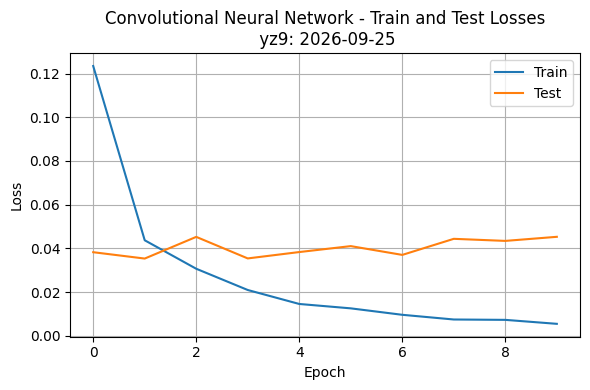

In [13]:
# Plot train and test losses for the convolutional neural network
visualize.visualize_loss(cnn_train_losses, cnn_test_losses, "Convolutional Neural Network")

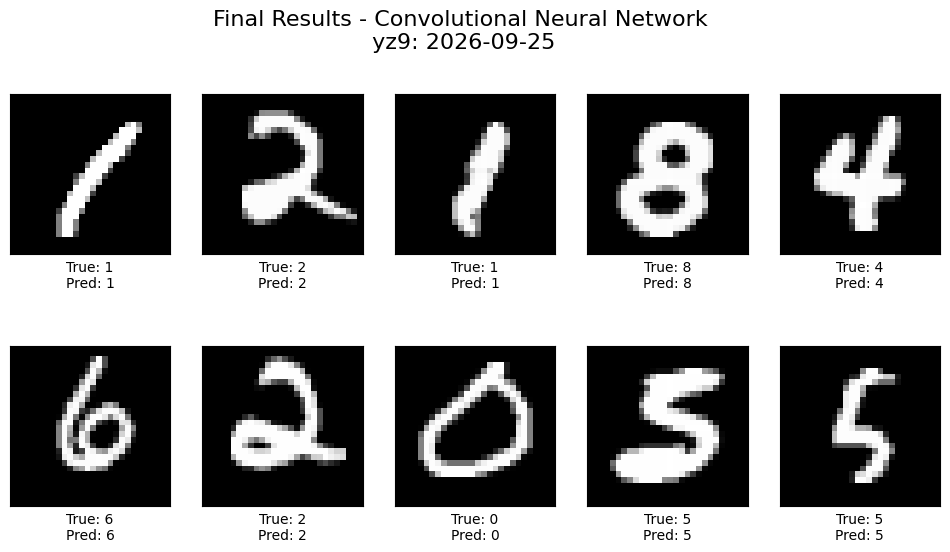

In [14]:
# Visualize the final results
visualize.visualize_images(cnn_model, testloader.dataset, device, "Convolutional Neural Network")

# PLOT T-SNE To Visualise Learning

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique used for visualizing high-dimensional data in lower-dimensional spaces. It's commonly used to explore patterns and relationships in complex data by mapping similar data points closer to each other in the lower-dimensional space.

To implement t-SNE without PyTorch, you can use the scikit-learn library, which provides an easy-to-use implementation of t-SNE. Here's how you can implement t-SNE without TensorFlow and instructions for a student assignment:

Implement t-SNE with scikit-learn or custom written function

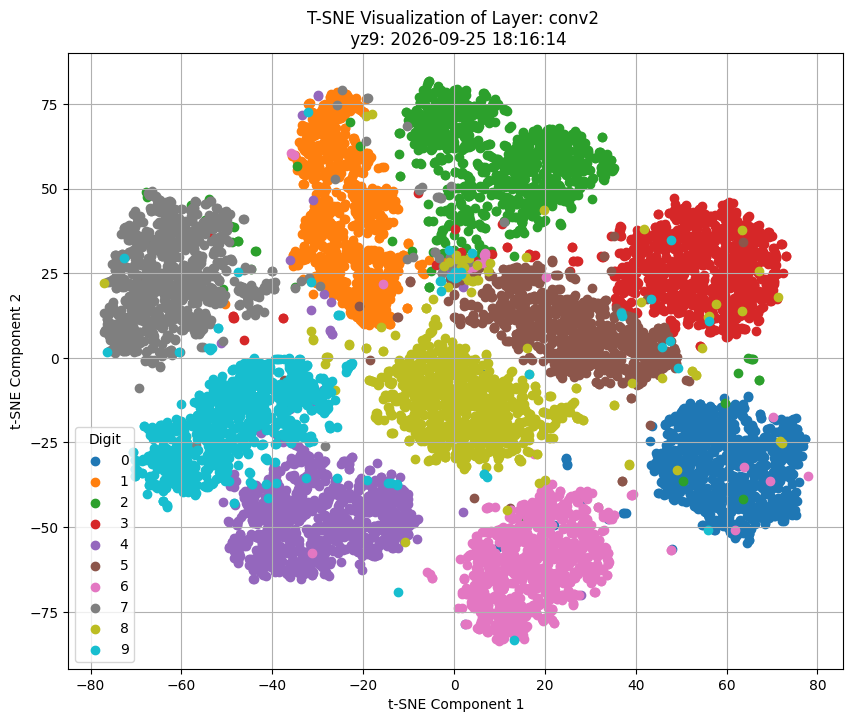

In [15]:
# Snapshot results and paste in Q1) Part3

from sklearn.manifold import TSNE
import datetime
import student_profile

testset = testloader.dataset
current_datetime = datetime.datetime.now()
timestamp_str = current_datetime.strftime('%Y-%m-%d %H:%M:%S')

# Choose the layer for visualization (e.g., conv1 or conv2)
# TODO
selected_layer = "conv2"

# Extract activations from the selected layer for all test images
activations = []
with torch.no_grad():
    for inputs, _ in testloader:
        inputs = inputs.to(device)
        x = cnn_model.conv1(inputs)
        x = cnn_model.relu1(x)
        x = cnn_model.pool(x)
        x = cnn_model.conv2(x)
        layer_output = cnn_model.relu2(x)
        activations.append(layer_output.view(layer_output.size(0), -1).cpu())
        # TODO use selected layer
        # activations.append(...) append to activations with the correct resizing using .view()
activations = torch.cat(activations, dim=0)

# Convert activations to numpy array
activations_np = activations.numpy()

# Apply t-SNE to reduce dimensions to 2 for visualization
# TODO: read the documentation for sklearn.manifold.TSNE to understand the parameters and input shapes
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
tsne = TSNE(n_components=2, random_state=42)
activations_tsne = tsne.fit_transform(activations_np)

# Plot the t-SNE visualization
plt.figure(figsize=(10, 8))
for i in range(10):
    plt.scatter(
        activations_tsne[testset.targets.numpy() == i, 0],
        activations_tsne[testset.targets.numpy() == i, 1],
        label=str(i)
    )

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Digit')
plt.title(f'T-SNE Visualization of Layer: {selected_layer} \n {student_profile.andrew_id}: {timestamp_str}')
plt.grid(True)
plt.show()